In [1]:
import pandas as pd

### Load single-cell data

In [2]:
%%time
df = pd.read_pickle('/Users/dayn/data/macrohet_mac/verified_df.pkl')


CPU times: user 673 ms, sys: 348 ms, total: 1.02 s
Wall time: 1.22 s


In [3]:
df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.0,85.30408,914.186190,980.270593,0.0,0.0,1.0,716.326599,843.3125,...,NaN,0.0,0.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,0,7.0
1,0.5,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,0.5,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,1,7.0
2,1.0,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,1.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,2,7.0
3,1.5,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,1.5,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,3,7.0
4,2.0,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,2.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,4,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007856,59.5,0.0,NaN,261.387613,NaN,False,0.0,0.0,1034.000000,1161.0000,...,NaN,0.0,58.5,0.0,None,None,None,-1.02,119,NaN
2007857,60.0,0.0,NaN,275.109568,NaN,False,0.0,0.0,972.000000,1147.0000,...,NaN,0.0,59.0,0.0,None,None,None,-1.02,120,NaN
2007858,60.5,0.0,NaN,404.484815,NaN,False,0.0,0.0,948.000000,1159.0000,...,NaN,0.0,59.5,0.0,None,None,None,-1.02,121,NaN
2007859,61.0,0.0,NaN,297.055758,NaN,NaN,0.0,0.0,874.000000,1163.0000,...,NaN,0.0,NaN,NaN,None,None,None,-1.02,122,NaN


### Now intrinsic growth versus extrinsic etc 

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_12102/717268820.py:98: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_12102/717268820.py:98: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_12102/717268820.py:144: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin.set_yticklabels(order, fontweight='bold', fontsize=8) # Smaller Y labels
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_12102/717268820.py:267: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig('/Volumes/OPERA3/Nathan/data/

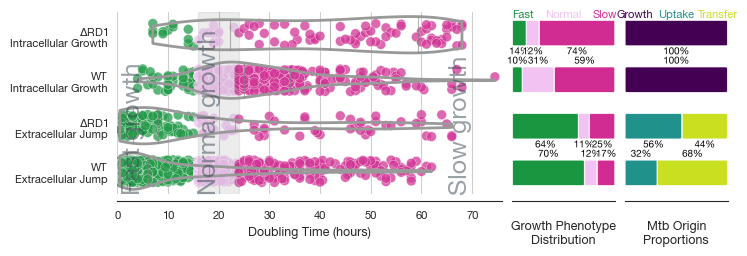

In [40]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

# --- Global Style & Font Settings ---
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")
sns.set_style("white")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica Neue']
plt.rcParams['pdf.fonttype'] = 42 

# --- Contextual Definitions ---
growth_colors = {
    "Fast": '#1a9641',   # Deep Green
    "Normal": '#F1C2F2', # Light Pink/Purple
    "Slow": '#D02C91'    # Deep Magenta
}
growth_order = ["Fast", "Normal", "Slow"]

# --- CONTROL VARIABLE FOR PANEL 3 COLOURS ---
origin_palette_list = ['#440154', '#21918c', '#c8e020'] 

origin_colors = {
    "Growth": origin_palette_list[0],   # Intrinsic
    "Uptake": origin_palette_list[1],   # Uptake
    "Transfer": origin_palette_list[2]  # Transfer
}
origin_order = ["Growth", "Uptake", "Transfer"]

# Dimensions (Updated for 200mm x 60mm)
width_mm = 200 
height_mm = 60
width_in = width_mm / 25.4
height_in = height_mm / 25.4

# --- Data Preparation ---
subset_df = df[df['Compound']=='CTRL'].copy()
subset_df = subset_df[subset_df['mtb_origin'].isin(['Growth', 'Uptake', 'Transfer'])]
subset_df = subset_df.drop_duplicates('ID')

# Flatten Doubling Times
subset_df = subset_df.explode("Doubling Times", ignore_index=True)
subset_df["Doubling Times"] = pd.to_numeric(subset_df["Doubling Times"], errors="coerce")
subset_df = subset_df.dropna(subset=["Doubling Times"])
subset_df = subset_df[(subset_df["Doubling Times"] > 0) & (~np.isinf(subset_df["Doubling Times"]))]

# Update Labels for Greek Delta
subset_df['Display_Strain'] = subset_df['Strain'].replace({'RD1': r'$\Delta$RD1'})
# Label rows with a newline between strain and description
subset_df['Growth_Label'] = subset_df.apply(
    lambda row: f"{row['Display_Strain']}\nIntracellular Growth" if row['mtb_origin'] == 'Growth'
                else f"{row['Display_Strain']}\nExtracellular Jump", axis=1
)

# Explicit Order must match the new strings exactly
order = [
    r'$\Delta$RD1' + '\nIntracellular Growth',
    'WT' + '\nIntracellular Growth', 
    r'$\Delta$RD1' + '\nExtracellular Jump',
    'WT' + '\nExtracellular Jump'
]


# Binning
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels=labels, right=False)

# --- Plotting Layout ---
fig = plt.figure(figsize=(width_in, height_in), constrained_layout=True)
gs = gridspec.GridSpec(1, 3, width_ratios=[3, 0.8, 0.8], wspace=0.05)

ax_violin = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])
ax_origin = plt.subplot(gs[2])

# ==========================================
# PANEL 1: VIOLIN & STRIP
# ==========================================
for cat in growth_order:
    cat_df = subset_df[subset_df["Growth Category"] == cat]
    if cat_df.empty: continue
    
    sns.stripplot(
        data=cat_df, x="Doubling Times", y="Growth_Label",
        order=order, hue="Display_Strain", palette={s: growth_colors[cat] for s in subset_df['Display_Strain'].unique()},
        # Reduced size for smaller plot
        dodge=False, jitter=0.25, size=7, linewidth=0.3, 
        edgecolor='white', alpha=0.75, ax=ax_violin, zorder=1, legend=False
    )

sns.violinplot(
    data=subset_df, x="Doubling Times", y="Growth_Label",
    order=order, hue="Display_Strain", dodge=False,    
    inner="quartile", cut=0, scale='width',    
    linewidth=2, linecolor='gray', # Thinner lines
    palette={s: "white" for s in subset_df['Display_Strain'].unique()}, 
    saturation=1, ax=ax_violin, zorder=2, legend=False
)

for line in ax_violin.lines:
    line.set_linestyle('-')
    line.set_linewidth(0.8) # Thinner quartiles
    line.set_color('gray')
    line.set_alpha(0.6)

for poly in ax_violin.collections:
    if "PolyCollection" in str(type(poly)):
        poly.set_facecolor('none') 

xmax = 76
bands = [("Fast", bins[0], bins[1], 0.05), 
         ("Normal", bins[1], bins[2], 0.15), 
         ("Slow", bins[2], xmax, 0.05)]

for txt, b0, b1, alpha in bands:
    color = 'gray' if txt=='Normal' else 'white'        
    ax_violin.axvspan(b0, b1, alpha=alpha, color=color)

labels_info = [("Fast growth", 1, "left"), 
                ("Normal growth", 16, "left"), 
                ("Slow growth", 70, "right")]

for txt, xpos, align in labels_info:
    # Reduced fontsize from 28 to 12
    ax_violin.text(xpos, 0., txt, fontsize=18, color='#36454F', 
                    alpha=0.5, ha=align, va='bottom', 
                    rotation=90, family='Helvetica Neue',
                    transform=ax_violin.get_xaxis_transform())

ax_violin.set_xlabel('Doubling Time (hours)', family='Helvetica Neue', fontsize=9)
ax_violin.set_ylabel(None)
ax_violin.set_xlim(0, xmax)
ax_violin.set_xticks([0, 10, 20, 30, 40, 50, 60, 70])
ax_violin.tick_params(axis='both', labelsize=8) # Smaller tick labels
ax_violin.xaxis.grid(True)
sns.despine(offset=5, left=True, ax=ax_violin) # Reduced offset
ax_violin.set_yticklabels(order, fontweight='bold', fontsize=8) # Smaller Y labels


# ==========================================
# PANEL 2: PHENOTYPE STACKED BARS
# ==========================================
g = (subset_df.groupby(["Growth_Label", "Growth Category"], observed=True)
        .size().unstack("Growth Category", fill_value=0))
g = g.reindex(order)
props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

y_pos = np.arange(len(order))
bar_height = 0.55
lefts = np.zeros(len(props))

for gr in growth_order:
    if gr not in props.columns: continue
    vals = props[gr].values
    bars = ax_bar.barh(y_pos, vals, left=lefts, height=bar_height, color=growth_colors[gr], edgecolor="none")
    
    for idx, bar in enumerate(bars):
        width = bar.get_width()
        if width <= 0: continue
        fancy_box = mpatches.FancyBboxPatch(
            (bar.get_x(), bar.get_y()), width, bar.get_height(),
            boxstyle="round,pad=-0.005,rounding_size=0.04",
            facecolor=bar.get_facecolor(), edgecolor="white", linewidth=0.5, mutation_scale=0.5
        )
        ax_bar.add_patch(fancy_box)
        bar.set_visible(False) 
    
    shift_amount = 0.4
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.05: 
            x_c = bar.get_x() + bar.get_width() / 2
            y_c = (bar.get_y() + bar.get_height() / 2) + (shift_amount if i % 2 == 0 else -shift_amount)
            
            # Reduced percentage fontsize to 7
            txt = ax_bar.text(x_c, y_c, f"{v*100:.0f}%", ha="center", va="center", 
                        fontsize=7, fontweight="bold", family='Helvetica Neue', color='black')
            # Thinner stroke
            txt.set_path_effects([path_effects.withStroke(linewidth=1.5, foreground='white')])
            
    lefts += vals

# Fixed Labels Panel 2
fixed_x_positions = {"Fast": 0.1, "Normal": 0.5, "Slow": 0.9}
for gr in growth_order:
    # Reduced label fontsize to 8
    ax_bar.text(fixed_x_positions[gr], -0.3, gr, ha='center', va='bottom', 
                fontsize=8, fontweight='bold', color=growth_colors[gr], family='Helvetica Neue')
        
ax_bar.set(xlim=(0, 1), xticks=[], ylabel="")
ax_bar.set_xlabel("\nGrowth Phenotype\nDistribution", family='Helvetica Neue', fontsize=9)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels([]) 
ax_bar.invert_yaxis()
sns.despine(offset=5, left=True, ax=ax_bar)


# ==========================================
# PANEL 3: ORIGIN STACKED BARS
# ==========================================
origin_counts = subset_df.groupby(['Growth_Label', 'mtb_origin']).size().unstack(fill_value=0)
origin_counts = origin_counts.reindex(order)
for col in origin_order:
    if col not in origin_counts.columns: origin_counts[col] = 0
origin_counts = origin_counts[origin_order]

origin_props = origin_counts.div(origin_counts.sum(axis=1), axis=0).fillna(0.0)

lefts_origin = np.zeros(len(origin_props))

for org in origin_order:
    vals = origin_props[org].values
    bars = ax_origin.barh(y_pos, vals, left=lefts_origin, height=bar_height, 
                          color=origin_colors[org], edgecolor="none")
    
    for idx, bar in enumerate(bars):
        width = bar.get_width()
        if width <= 0: continue
        fancy_box = mpatches.FancyBboxPatch(
            (bar.get_x(), bar.get_y()), width, bar.get_height(),
            boxstyle="round,pad=-0.005,rounding_size=0.04",
            facecolor=bar.get_facecolor(), edgecolor="white", linewidth=0.5, mutation_scale=0.5
        )
        ax_origin.add_patch(fancy_box)
        bar.set_visible(False)

    # Percentage Labels
    shift_amount = 0.4
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.05: 
            x_c = bar.get_x() + bar.get_width() / 2
            y_c = (bar.get_y() + bar.get_height() / 2) + (shift_amount if i % 2 == 0 else -shift_amount)
            
            # Reduced percentage fontsize to 7
            txt = ax_origin.text(x_c, y_c, f"{v*100:.0f}%", ha="center", va="center", 
                        fontsize=7, fontweight="bold", family='Helvetica Neue', color='black')
            txt.set_path_effects([path_effects.withStroke(linewidth=1.5, foreground='white')])

    lefts_origin += vals

# Fixed Labels Panel 3
fixed_x_origin = {
    "Growth": 0.1, 
    "Uptake": 0.5, 
    "Transfer": 0.9
}

for org in origin_order:
    # Reduced label fontsize to 8
    ax_origin.text(fixed_x_origin[org], -0.3, org, ha='center', va='bottom', 
                   fontsize=8, fontweight='bold', color=origin_colors[org], family='Helvetica Neue')

ax_origin.set(xlim=(0, 1), xticks=[], ylabel="")
ax_origin.set_xlabel("\nMtb Origin\nProportions", family='Helvetica Neue', fontsize=9)
ax_origin.set_yticks(y_pos)
ax_origin.set_yticklabels([]) 
ax_origin.invert_yaxis()
sns.despine(offset=5, left=True, ax=ax_origin)

# Save the plot
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/2D.pdf', 
            dpi=314, bbox_inches='tight')

plt.show()

In [6]:
segment_centers

{'Fast': np.float64(0.06818181818181818),
 'Normal': np.float64(0.19886363636363635),
 'Slow': np.float64(0.6306818181818181)}

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_84747/3619200336.py:65: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_84747/3619200336.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


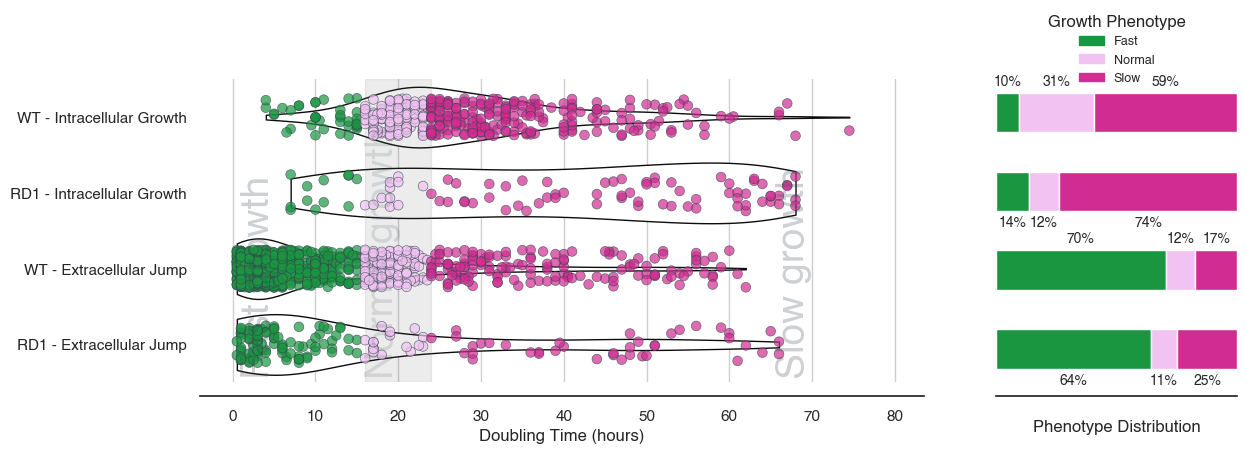

In [252]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

# --- Definitions & Style Setup ---
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']
fast_c, normal_c, slow_c = expanded_piyg[0], '#F1C2F2', '#D02C91'
growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}
growth_order = ["Fast", "Normal", "Slow"]

# Increased width slightly to accommodate the new panel while keeping aspect ratio
width_mm = 340 
height_mm = 100
width_in = width_mm / 25.4
height_in = height_mm / 25.4

# --- Data Preparation ---
# Create subset_df instead of overwriting df
subset_df = df[df['Compound']=='CTRL'].copy()
subset_df = subset_df[subset_df['mtb_origin'].isin(['Growth', 'Uptake', 'Transfer'])]
subset_df = subset_df.drop_duplicates('ID')

# Flatten Doubling Times
subset_df = subset_df.explode("Doubling Times", ignore_index=True)
subset_df["Doubling Times"] = pd.to_numeric(subset_df["Doubling Times"], errors="coerce")
subset_df = subset_df.dropna(subset=["Doubling Times"])
subset_df = subset_df[(subset_df["Doubling Times"] > 0) & (~np.isinf(subset_df["Doubling Times"]))]

# Binning
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels=labels, right=False)

# Label rows
subset_df['Growth'] = subset_df.apply(
    lambda row: f"{row['Strain']} - Intracellular Growth" if row['mtb_origin'] == 'Growth'
                else f"{row['Strain']} - Extracellular Jump", axis=1
)

# Order
order = [
    'WT - Intracellular Growth', 
    'RD1 - Intracellular Growth',
    'WT - Extracellular Jump', 
    'RD1 - Extracellular Jump'
]

# --- Plotting Layout ---
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.15)

ax_violin = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# ===========================
# LEFT PANEL: VIOLIN & STRIP
# ===========================

# 1. Base Violin
white_palette = {s: "white" for s in subset_df['Strain'].unique()}

sns.violinplot(
    data=subset_df, x="Doubling Times", y="Growth",
    order=order, hue="Strain", dodge=False,    
    inner=None, cut=0, scale='width',    
    linewidth=1.0, linecolor='black',
    palette=white_palette, saturation=1, ax=ax_violin
)
if ax_violin.legend_: ax_violin.legend_.remove()

# 2. Stripplots
for cat in growth_order:
    cat_df = subset_df[subset_df["Growth Category"] == cat]
    if cat_df.empty: continue
    
    current_hues = cat_df["Strain"].unique()
    palette_map = {h: growth_colors[cat] for h in current_hues}
    
    sns.stripplot(
        data=cat_df, x="Doubling Times", y="Growth",
        order=order, hue="Strain", palette=palette_map,
        dodge=False, jitter=0.25, size=7, linewidth=0.5, 
        edgecolor='#36454F', alpha=0.7, ax=ax_violin
    )
    if ax_violin.legend_: ax_violin.legend_.remove()

# Background Bands
xmax = subset_df["Doubling Times"].max() if not subset_df["Doubling Times"].isna().all() else 75
bands = [("Fast", bins[0], bins[1], 0.05), 
         ("Normal", bins[1], bins[2], 0.15), 
         ("Slow", bins[2], xmax+5, 0.05)]

for txt, b0, b1, alpha in bands:
    shaded_region_colour = 'gray' if txt=='Normal' else 'white'        
    ax_violin.axvspan(b0, b1, alpha=alpha, color=shaded_region_colour)

# Annotations
ymax = len(order) - 0.65 
labels_info = [("Fast growth", 1, "left", 0.25), 
               ("Normal growth", 16, "left", 0.15), 
               ("Slow growth", 70, "right", 0.25)]

for txt, xpos, align, alpha in labels_info:
    ax_violin.text(xpos, ymax, txt, fontsize=28, color='#36454F', 
                   alpha=alpha, ha=align, rotation=90)

ax_violin.set_xlabel('Doubling Time (hours)')
ax_violin.set_ylabel('')
ax_violin.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax_violin)


# ===========================
# RIGHT PANEL: STACKED BARS
# ===========================

# Group Data by 'Growth' (y-axis label) and Category
g = (subset_df.groupby(["Growth", "Growth Category"], observed=True)
        .size().unstack("Growth Category", fill_value=0))

# Ensure rows align with the violin plot order
g = g.reindex(order)
props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

# Bar Parameters
y_pos = np.arange(len(order))
bar_height = 0.5
lefts = np.zeros(len(props))

for gr in growth_order:
    if gr not in props.columns: continue
    vals = props[gr].values
    
    bars = ax_bar.barh(y_pos, vals, left=lefts, height=bar_height, 
                       label=gr, color=growth_colors[gr], edgecolor="white")
    
    # --- Alternating Label Logic ---
    shift_amount = 0.40 
    
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.05: 
            x_center = bar.get_x() + bar.get_width() / 2
            base_y = bar.get_y() + bar.get_height() / 2
            
            # Alternate up/down
            if i % 2 == 0:
                y_center = base_y - shift_amount
            else:
                y_center = base_y + shift_amount
            
            ax_bar.text(x_center, y_center, 
                        f"{v*100:.0f}%", 
                        ha="center", va="center", fontsize=10, fontweight="bold",
                        bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))
    # -------------------------------
            
    lefts += vals

ax_bar.set(xlim=(0, 1), xticks=[], ylabel="", xlabel="\nPhenotype Distribution")
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels([]) # Labels are shared with left plot
ax_bar.invert_yaxis()      # Ensure alignment with violin plot (Top-down)
sns.despine(offset=10, left=True, ax=ax_bar)

# Legend
handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in growth_order]
ax_bar.legend(handles=handles, title="Growth Phenotype", loc="upper center", 
              frameon=False, bbox_to_anchor=(0.5, 1.25), ncol=1, fontsize=9)

plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/fig3D_intrinsic_versus_extrinsic_combined.pdf', dpi=314, bbox_inches='tight')
plt.show()

# Stats 

KS Test Results: D=0.1701, p=4.0031e-02


<Figure size 640x480 with 0 Axes>

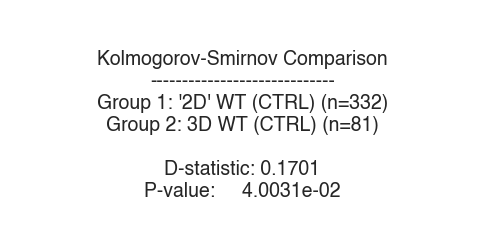

In [259]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy import stats  # Import for KS test

# ... [Previous Data Prep Parts 1-3 remain exactly the same] ...

# --- 3b. Perform KS Statistics ---
# Extract the arrays for comparison
data_2d = comp_df[comp_df["Experiment"] == "'2D' WT (CTRL)"]["Doubling Times"].values
data_3d = comp_df[comp_df["Experiment"] == "3D WT (CTRL)"]["Doubling Times"].values

# Run the Kolmogorov-Smirnov test
d_stat, p_val = stats.ks_2samp(data_2d, data_3d)

print(f"KS Test Results: D={d_stat:.4f}, p={p_val:.4e}")

# ... [Previous Plotting Code for the main figure remains exactly the same] ...

# --- Save Main Figure ---
output_dir = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/'
plt.savefig(f'{output_dir}3D_doubling_times_violin_plot_phenotype_colour_code_shifted_percentages.pdf', 
            bbox_inches='tight', dpi=314)
plt.show()

# --- Save Stats to PDF ---
# Create a small figure just for the text
fig_stat, ax_stat = plt.subplots(figsize=(6, 3))
ax_stat.axis('off')

# Format the stats text
stats_text = (
    f"Kolmogorov-Smirnov Comparison\n"
    f"-----------------------------\n"
    f"Group 1: '2D' WT (CTRL) (n={len(data_2d)})\n"
    f"Group 2: 3D WT (CTRL) (n={len(data_3d)})\n\n"
    f"D-statistic: {d_stat:.4f}\n"
    f"P-value:     {p_val:.4e}"
)

ax_stat.text(0.5, 0.5, stats_text, 
             ha='center', va='center', 
             fontsize=14, family='Helvetica')

# Save to the same directory with a _stats suffix
# plt.savefig(f'{output_dir}3D_doubling_times_KS_stats.pdf', 
#             bbox_inches='tight', dpi=314)
plt.show()
# plt.close(fig_stat)

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Prepare Data ---
# Using the cleaned 'subset_df' from your plotting code
data_rd1 = subset_df[subset_df["Strain"] == "RD1"]["Doubling Times"].values
data_wt = subset_df[subset_df["Strain"] == "WT"]["Doubling Times"].values

# --- 2. Run All 4 Statistical Tests ---

# A. Kolmogorov-Smirnov (KS)
ks_stat, ks_p = stats.ks_2samp(data_rd1, data_wt)

# B. Mann-Whitney U (MWU)
mwu_stat, mwu_p = stats.mannwhitneyu(data_rd1, data_wt, alternative='two-sided')

# C. Anderson-Darling (AD)
# Returns (statistic, critical_values, significance_level)
ad_res = stats.anderson_ksamp([data_rd1, data_wt])
ad_stat = ad_res.statistic
ad_p = ad_res.significance_level

# D. Cramér-von Mises (CvM)
cvm_res = stats.cramervonmises_2samp(data_rd1, data_wt)
cvm_stat = cvm_res.statistic
cvm_p = cvm_res.pvalue

# --- 3. Build Report Content ---
lines = []
lines.append("Statistical Comparison: RD1 vs WT Growth Dynamics")
lines.append("=================================================")
lines.append(f"Sample Sizes: RD1 (n={len(data_rd1)}), WT (n={len(data_wt)})\n")

# -- KS Test --
lines.append("1. Kolmogorov-Smirnov (KS) Test")
lines.append("   ----------------------------")
lines.append(f"   D-statistic: {ks_stat:.4f}")
lines.append(f"   P-value:     {ks_p:.4e}")
lines.append("   WHAT IT SHOWS: The maximum vertical distance between the two cumulative")
lines.append("   distributions. It is a general test for any difference (shape, spread,")
lines.append("   or median) but is most sensitive to shifts in the center of the distribution.\n")

# -- MWU Test --
lines.append("2. Mann-Whitney U Test")
lines.append("   -------------------")
lines.append(f"   U-statistic: {mwu_stat:.1f}")
lines.append(f"   P-value:     {mwu_p:.4e}")
lines.append("   WHAT IT SHOWS: Whether one population is stochastically greater than the")
lines.append("   other. Often used as a test for differences in medians. A significant")
lines.append("   result here specifically implies a 'speed' difference (faster vs slower).\n")

# -- AD Test --
lines.append("3. Anderson-Darling k-Sample Test")
lines.append("   ------------------------------")
lines.append(f"   Statistic:   {ad_stat:.4f}")
lines.append(f"   P-value:     {ad_p:.4f} (approx capped at 0.001)")
lines.append("   WHAT IT SHOWS: Similar to KS, but places more weight on the tails of the")
lines.append("   distribution. It is powerful for detecting if the strain difference specifically")
lines.append("   affects extreme sub-populations (e.g., persisters or fast-growers).\n")

# -- CvM Test --
lines.append("4. Cramér-von Mises Test")
lines.append("   ---------------------")
lines.append(f"   Statistic:   {cvm_stat:.4f}")
lines.append(f"   P-value:     {cvm_p:.4e}")
lines.append("   WHAT IT SHOWS: Considers the squared difference across the entire distribution")
lines.append("   rather than just the maximum point (like KS). It is a more robust 'goodness")
lines.append("   of fit' that accounts for the overall structural match between the two groups.\n")

# -- Summary --
sig_count = sum([1 for p in [ks_p, mwu_p, ad_p, cvm_p] if p < 0.05])
lines.append("--------------------------------------------------")
lines.append(f"SUMMARY CONCLUSION: {sig_count}/4 tests indicate a significant difference (p < 0.05).")

report_text = "\n".join(lines)
print(report_text)

# --- 4. Save to PDF ---
fig, ax = plt.subplots(figsize=(8.5, 11))
ax.axis('off')

ax.text(0.05, 0.95, report_text, 
        transform=ax.transAxes, 
        fontsize=10, 
        fontfamily='monospace', 
        va='top', ha='left')

output_dir = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/'
save_path = f'{output_dir}RD1_vs_WT_Comprehensive_Stats_Report.pdf'

plt.savefig(save_path, bbox_inches='tight', dpi=314)
plt.close(fig)

print(f"Stats Report saved to: {save_path}")

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_84747/192343278.py:21: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_res = stats.anderson_ksamp([data_rd1, data_wt])


Statistical Comparison: RD1 vs WT Growth Dynamics
Sample Sizes: RD1 (n=248), WT (n=1228)

1. Kolmogorov-Smirnov (KS) Test
   ----------------------------
   D-statistic: 0.2054
   P-value:     4.1762e-08
   WHAT IT SHOWS: The maximum vertical distance between the two cumulative
   distributions. It is a general test for any difference (shape, spread,
   or median) but is most sensitive to shifts in the center of the distribution.

2. Mann-Whitney U Test
   -------------------
   U-statistic: 179795.5
   P-value:     6.8641e-06
   WHAT IT SHOWS: Whether one population is stochastically greater than the
   other. Often used as a test for differences in medians. A significant
   result here specifically implies a 'speed' difference (faster vs slower).

3. Anderson-Darling k-Sample Test
   ------------------------------
   Statistic:   25.1333
   P-value:     0.0010 (approx capped at 0.001)
   WHAT IT SHOWS: Similar to KS, but places more weight on the tails of the
   distribution. It is p

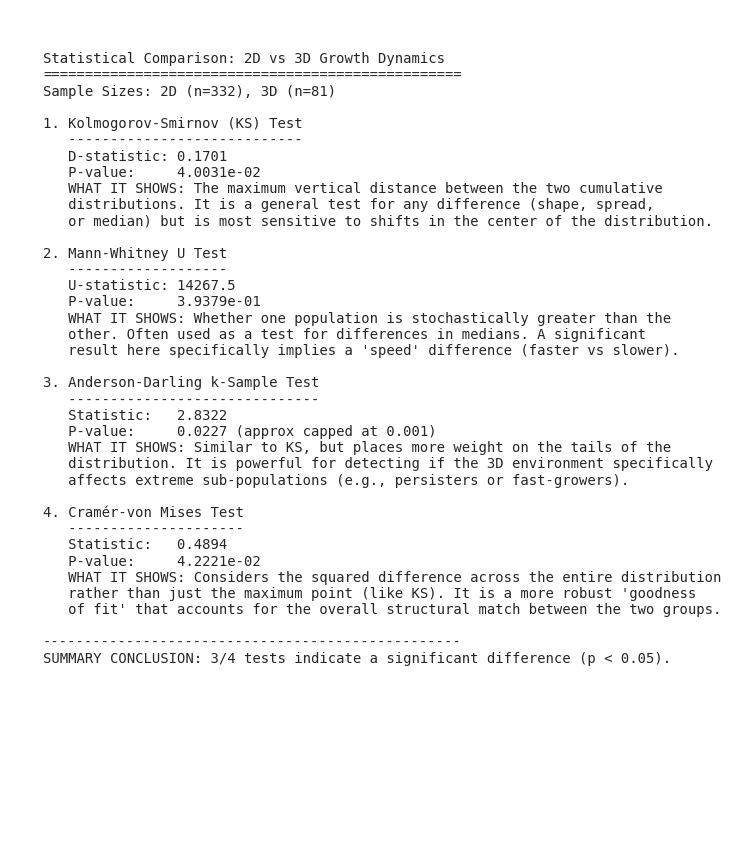

Report saved to: /Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/3D_vs_2D_Comprehensive_Stats_Report.pdf


In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Prepare Data ---
# (Assumes comp_df exists from previous steps)
data_2d = comp_df[comp_df["Experiment"] == "'2D' WT (CTRL)"]["Doubling Times"].values
data_3d = comp_df[comp_df["Experiment"] == "3D WT (CTRL)"]["Doubling Times"].values

# --- 2. Run Tests ---

# A. Kolmogorov-Smirnov (KS)
ks_stat, ks_p = stats.ks_2samp(data_2d, data_3d)

# B. Mann-Whitney U (MWU)
mwu_stat, mwu_p = stats.mannwhitneyu(data_2d, data_3d, alternative='two-sided')

# C. Anderson-Darling (AD)
ad_res = stats.anderson_ksamp([data_2d, data_3d])
ad_stat = ad_res.statistic
ad_p = ad_res.significance_level

# D. Cramér-von Mises (CvM)
cvm_res = stats.cramervonmises_2samp(data_2d, data_3d)
cvm_stat = cvm_res.statistic
cvm_p = cvm_res.pvalue

# --- 3. Build Report Content ---
lines = []
lines.append("Statistical Comparison: 2D vs 3D Growth Dynamics")
lines.append("==================================================")
lines.append(f"Sample Sizes: 2D (n={len(data_2d)}), 3D (n={len(data_3d)})\n")

# -- KS Test --
lines.append("1. Kolmogorov-Smirnov (KS) Test")
lines.append("   ----------------------------")
lines.append(f"   D-statistic: {ks_stat:.4f}")
lines.append(f"   P-value:     {ks_p:.4e}")
lines.append("   WHAT IT SHOWS: The maximum vertical distance between the two cumulative")
lines.append("   distributions. It is a general test for any difference (shape, spread,")
lines.append("   or median) but is most sensitive to shifts in the center of the distribution.\n")

# -- MWU Test --
lines.append("2. Mann-Whitney U Test")
lines.append("   -------------------")
lines.append(f"   U-statistic: {mwu_stat:.1f}")
lines.append(f"   P-value:     {mwu_p:.4e}")
lines.append("   WHAT IT SHOWS: Whether one population is stochastically greater than the")
lines.append("   other. Often used as a test for differences in medians. A significant")
lines.append("   result here specifically implies a 'speed' difference (faster vs slower).\n")

# -- AD Test --
lines.append("3. Anderson-Darling k-Sample Test")
lines.append("   ------------------------------")
lines.append(f"   Statistic:   {ad_stat:.4f}")
lines.append(f"   P-value:     {ad_p:.4f} (approx capped at 0.001)")
lines.append("   WHAT IT SHOWS: Similar to KS, but places more weight on the tails of the")
lines.append("   distribution. It is powerful for detecting if the 3D environment specifically")
lines.append("   affects extreme sub-populations (e.g., persisters or fast-growers).\n")

# -- CvM Test --
lines.append("4. Cramér-von Mises Test")
lines.append("   ---------------------")
lines.append(f"   Statistic:   {cvm_stat:.4f}")
lines.append(f"   P-value:     {cvm_p:.4e}")
lines.append("   WHAT IT SHOWS: Considers the squared difference across the entire distribution")
lines.append("   rather than just the maximum point (like KS). It is a more robust 'goodness")
lines.append("   of fit' that accounts for the overall structural match between the two groups.\n")

# -- Summary --
sig_count = sum([1 for p in [ks_p, mwu_p, ad_p, cvm_p] if p < 0.05])
lines.append("--------------------------------------------------")
lines.append(f"SUMMARY CONCLUSION: {sig_count}/4 tests indicate a significant difference (p < 0.05).")

report_text = "\n".join(lines)

# --- 4. Render to PDF ---
fig, ax = plt.subplots(figsize=(8.5, 11))
ax.axis('off')

ax.text(0.05, 0.95, report_text, 
        transform=ax.transAxes, 
        fontsize=10, 
        fontfamily='monospace', 
        va='top', ha='left')

output_dir = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/'
save_path = f'{output_dir}3D_vs_2D_Comprehensive_Stats_Report.pdf'

plt.savefig(save_path, bbox_inches='tight', dpi=314)
plt.show(fig)

print(f"Report saved to: {save_path}")

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Prepare Data ---
# (Assumes 'subset_df' is already loaded and cleaned from your plotting code)

def get_data(strain, condition):
    """Helper to extract Doubling Times for a specific Strain and Growth/Jump condition."""
    # Matches the 'Growth' column logic from your plotting script:
    # "WT - Intracellular Growth", "WT - Extracellular Jump", etc.
    label = f"{strain} - {condition}" 
    return subset_df[subset_df["Growth"] == label]["Doubling Times"].values

# Define the comparisons we want to make
comparisons = [
    ("WT", "Intracellular Growth", "Extracellular Jump"),
    ("RD1", "Intracellular Growth", "Extracellular Jump")
]

# --- 2. Run Tests & Build Report ---
lines = []
lines.append("Statistical Comparison: Intracellular Growth vs Extracellular Jump")
lines.append("==================================================================")

for strain, group1, group2 in comparisons:
    data_g1 = get_data(strain, group1)
    data_g2 = get_data(strain, group2)
    
    lines.append(f"\nAnalysis for Strain: {strain}")
    lines.append(f"-------------------------")
    lines.append(f"Comparison: {group1} (n={len(data_g1)}) vs {group2} (n={len(data_g2)})\n")

    # A. Kolmogorov-Smirnov (KS)
    ks_stat, ks_p = stats.ks_2samp(data_g1, data_g2)
    
    # B. Mann-Whitney U (MWU)
    mwu_stat, mwu_p = stats.mannwhitneyu(data_g1, data_g2, alternative='two-sided')
    
    # C. Anderson-Darling (AD)
    try:
        ad_res = stats.anderson_ksamp([data_g1, data_g2])
        ad_stat = ad_res.statistic
        ad_p = ad_res.significance_level
    except:
        ad_stat, ad_p = np.nan, np.nan # Handle cases with insufficient data points

    # D. Cramér-von Mises (CvM)
    cvm_res = stats.cramervonmises_2samp(data_g1, data_g2)
    cvm_stat = cvm_res.statistic
    cvm_p = cvm_res.pvalue
    
    # Append results to report
    lines.append(f"1. Kolmogorov-Smirnov:   D={ks_stat:.4f}, p={ks_p:.4e}")
    lines.append(f"2. Mann-Whitney U:       U={mwu_stat:.1f}, p={mwu_p:.4e}")
    lines.append(f"3. Anderson-Darling:     Stat={ad_stat:.4f}, p={ad_p:.4f}")
    lines.append(f"4. Cramér-von Mises:     Stat={cvm_stat:.4f}, p={cvm_p:.4e}")
    
    sig_count = sum([1 for p in [ks_p, mwu_p, ad_p, cvm_p] if p < 0.05])
    lines.append(f"\n   -> Conclusion: {sig_count}/4 tests are significant (p < 0.05).")
    lines.append("-" * 60)

# Add Legend/Description at the bottom
lines.append("\nTest Descriptions:")
lines.append("KS: General distribution difference (center-weighted).")
lines.append("MWU: Difference in medians (speed shift).")
lines.append("AD: Difference in tails (persisters/outliers).")
lines.append("CvM: Robust goodness-of-fit (overall structure).")

report_text = "\n".join(lines)
print(report_text)

# --- 3. Save to PDF ---
fig, ax = plt.subplots(figsize=(8.5, 11))
ax.axis('off')

# Use a monospace font for table-like alignment
ax.text(0.05, 0.95, report_text, 
        transform=ax.transAxes, 
        fontsize=10, 
        fontfamily='monospace', 
        va='top', ha='left')

output_dir = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/'
save_path = f'{output_dir}Intrinsic_vs_Extrinsic_Stats_Report.pdf'

plt.savefig(save_path, bbox_inches='tight', dpi=314)
plt.close(fig)

print(f"Stats Report saved to: {save_path}")

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_84747/1979060172.py:43: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_res = stats.anderson_ksamp([data_g1, data_g2])


Statistical Comparison: Intracellular Growth vs Extracellular Jump

Analysis for Strain: WT
-------------------------
Comparison: Intracellular Growth (n=390) vs Extracellular Jump (n=838)

1. Kolmogorov-Smirnov:   D=0.6190, p=2.9134e-96
2. Mann-Whitney U:       U=272684.5, p=1.1555e-79
3. Anderson-Darling:     Stat=250.9003, p=0.0010
4. Cramér-von Mises:     Stat=40.3938, p=1.2378e-08

   -> Conclusion: 4/4 tests are significant (p < 0.05).
------------------------------------------------------------

Analysis for Strain: RD1
-------------------------
Comparison: Intracellular Growth (n=88) vs Extracellular Jump (n=160)

1. Kolmogorov-Smirnov:   D=0.5295, p=3.9081e-15
2. Mann-Whitney U:       U=11604.0, p=3.0031e-17
3. Anderson-Darling:     Stat=47.7880, p=0.0010
4. Cramér-von Mises:     Stat=7.3608, p=5.2985e-10

   -> Conclusion: 4/4 tests are significant (p < 0.05).
------------------------------------------------------------

Test Descriptions:
KS: General distribution difference 

In [126]:
# Define the expanded_piyg color map
expanded_piyg = [
    '#1a9641',  # First color from sns.color_palette('PiYG')
    '#a6d96a',  # Second color from sns.color_palette('PiYG')
    '#978897',  # Rose Quartz in hexadecimal format
    '#d1d1ca',  # Timberwolf in RGB normalized form
    '#f1b6da',  # Second-to-last color from sns.color_palette('PiYG')
    '#d02c91'   # Last color from sns.color_palette('PiYG')
]

def get_qualitative_desc(cv):
    """Categorizes CV into a qualitative description."""
    if cv < 0.2:
        return "Very Homogeneous"
    elif cv < 0.4:
        return "Homogeneous"
    elif cv < 0.6:
        return "Moderate Heterogeneity"
    elif cv < 0.8:
        return "High Heterogeneity"
    else:
        return "Extreme Heterogeneity"

In [122]:
import numpy as np
import pandas as pd

# 1. Normalize basics to string to avoid type errors
for c in ["Compound", "Strain"]:
    df[c] = df[c].astype(str)

# 2. Standardize Concentration (Handle missing values and CTRL logic)
df["Concentration"] = df.get("Concentration", pd.Series(["EC0"]*len(df))).fillna("EC0").astype(str)
df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

# 3. Normalize Strain names (Create Strain_norm)
rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")

# 4. Generate KDE_Hue
df["Condition"] = np.where(
    df["Compound"].eq("CTRL"),
    df["Strain_norm"] + " (CTRL)",
    df["Compound"] + " (" + df["Concentration"] + ")"
)

In [123]:
df["Condition"].unique()

array(['INH (EC50)', 'WT (CTRL)', 'PZA (EC50)', 'INH (EC99)',
       'PZA (EC99)', 'RIF (EC99)', 'RIF (EC50)', 'RD1 (CTRL)'],
      dtype=object)

### SD, CV and whether ornot there is bimodal distribution

In [124]:
# Filter for Growth -> Drop rows where 'Doubling Times' is NaN -> Create a clean copy
df = df[df['mtb_origin'] == 'Growth'].dropna(subset=['Doubling Times']).drop_duplicates('ID').explode('Doubling Times').copy()
df = df[df['Doubling Times'] > 0]

In [127]:


# Calculate mean and std for each group
df_stats = df.groupby('Condition')['Doubling Times'].agg(['mean', 'std']).reset_index()

# Calculate the Coefficient of Variation (CV)
df_stats['cv'] = df_stats['std'] / df_stats['mean']

# --- NEW: Apply qualitative function ---
df_stats['description'] = df_stats['cv'].apply(get_qualitative_desc)

# Create a lookup dictionary for plotting
# The format will be: {'WT (CTRL)': {'mean': 22.1, 'std': 3.4, 'cv': 0.15}, ...}
stats_lookup = df_stats.set_index('Condition').to_dict('index')

df_stats

,Condition,mean,std,cv,description
0,INH (EC50),31.623711,14.920803,0.471823,Moderate Heterogeneity
1,INH (EC99),31.287234,18.937180,0.605269,High Heterogeneity
2,PZA (EC50),30.745098,13.009755,0.423149,Moderate Heterogeneity
3,PZA (EC99),29.395833,17.344952,0.590048,Moderate Heterogeneity
4,RD1 (CTRL),40.102273,19.350541,0.48253,Moderate Heterogeneity
5,RIF (EC50),34.657143,15.895695,0.458656,Moderate Heterogeneity
6,RIF (EC99),18.318182,13.157965,0.718301,High Heterogeneity
7,WT (CTRL),27.980769,11.974599,0.427958,Moderate Heterogeneity


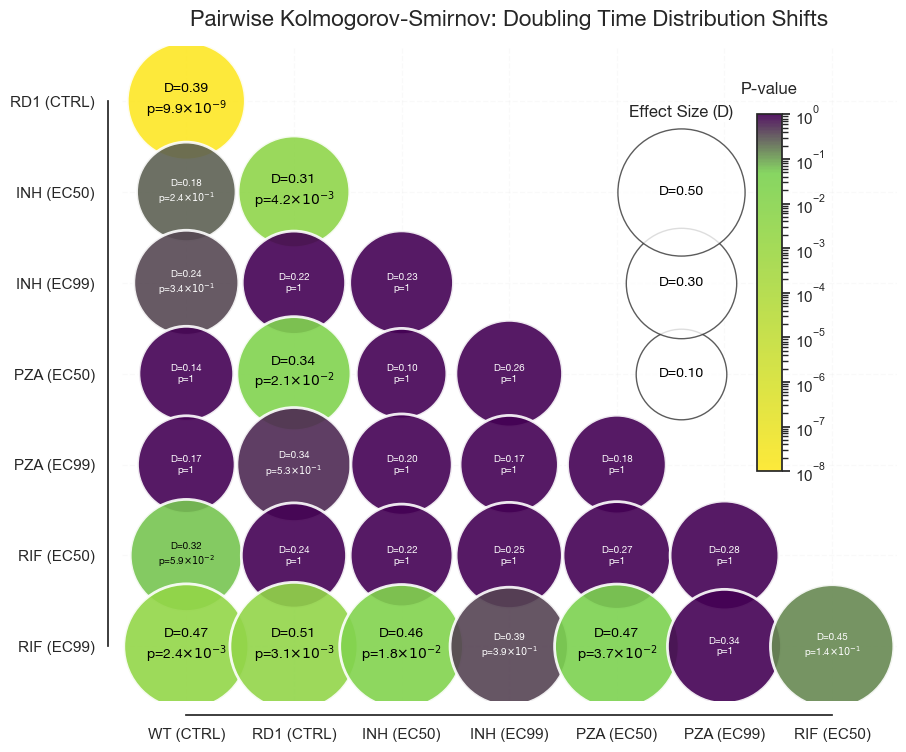

In [197]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from statsmodels.stats.multitest import multipletests

# --- 1. Prep Data and Order ---
target_order = [
    'WT (CTRL)', 'RD1 (CTRL)', 
    'INH (EC50)', 'INH (EC99)', 
    'PZA (EC50)', 'PZA (EC99)', 
    'RIF (EC50)', 'RIF (EC99)'
]

df['Condition'] = pd.Categorical(df['Condition'], categories=target_order, ordered=True)
groups = target_order 
pairs = list(combinations(groups, 2))

results = []
for g1, g2 in pairs:
    data1 = df[df['Condition'] == g1]['Doubling Times'].values
    data2 = df[df['Condition'] == g2]['Doubling Times'].values
    if len(data1) > 0 and len(data2) > 0:
        stat, p = stats.ks_2samp(data1, data2)
        results.append({'g1': g1, 'g2': g2, 'p': p, 'D': stat})

res_df = pd.DataFrame(results)
_, p_adj, _, _ = multipletests(res_df['p'], alpha=0.05, method='bonferroni')
res_df['p_adj'] = p_adj

# --- 2. Scaling & Custom Log-Centered Colormap ---
max_point_size = 8500 
d_min, d_max = res_df['D'].min(), res_df['D'].max()
res_df['scaled_size'] = (0.5 + 0.5 * (res_df['D'] - d_min) / (d_max - d_min)) * max_point_size

p_min = res_df['p_adj'].min()
log_min, log_max, log_mid = np.log10(p_min), np.log10(1.0), np.log10(0.05)
mid_pos = (log_mid - log_min) / (log_max - log_min)

v_base = plt.get_cmap('viridis_r')
custom_cmap = LinearSegmentedColormap.from_list('shifted_v', 
    [(0, v_base(0.001)), (mid_pos, v_base(0.2)), (1, v_base(1.0))])

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(10, 8.5))
sns.set_style("white")

group_to_idx = {g: i for i, g in enumerate(groups)}
x = res_df['g1'].map(group_to_idx)
y = res_df['g2'].map(group_to_idx)

scatter = ax.scatter(
    x, y, 
    s=res_df['scaled_size'],
    c=res_df['p_adj'],
    cmap=custom_cmap,
    norm=LogNorm(vmin=p_min, vmax=1.0),
    edgecolors='white',
    linewidth=2,
    alpha=0.9,
    zorder=3
)

# --- 4. Annotations with Smart Formatting ---
for i, row in res_df.iterrows():
    text_color = 'black' if row['p_adj'] < 0.06 else 'white'
    font_size = 10 if row['p_adj'] < 0.05 else 7
    
    base, exponent = f"{row['p_adj']:.1e}".split('e')
    exponent = int(exponent)
    
    if exponent == 0:
        p_str = "1"
    else:
        p_str = f"{base}" + r"$\times 10^{" + f"{exponent}" + r"}$"
        
    label = f"D={row['D']:.2f}\np={p_str}"
    
    ax.text(group_to_idx[row['g1']], group_to_idx[row['g2']], label,
            ha='center', va='center', fontsize=font_size, fontweight='bold',
            color=text_color, family='Helvetica Neue')

# --- 5. Formatting with INVERTED Y-AXIS ---
ax.invert_yaxis()

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, rotation=-45, ha='left', rotation_mode='anchor', family='Helvetica Neue')
ax.set_yticks(range(len(groups)))
ax.set_yticklabels(groups, family='Helvetica Neue')

ax.set_xlim(-0.6, len(groups) - 1.4)
ax.set_ylim(len(groups) - 0.4, 0.4) 

plt.grid(True, linestyle='--', alpha=0.1, zorder=0)
sns.despine(offset=10, trim=True)
ax.set_title("Pairwise Kolmogorov-Smirnov: Doubling Time Distribution Shifts", 
             fontsize=16, pad=15, family='Helvetica Neue', fontweight='bold')

# --- 6. Manual Legend (Shifted Left: x=4.6) ---
legend_x = [4.6, 4.6, 4.6] 
legend_y = [4.0, 3.0, 2.0] 

size_vals = [0.1, 0.3, 0.5] 
labels = [f"D={v:.2f}" for v in size_vals]

for lx, ly, s_val, lbl in zip(legend_x, legend_y, size_vals, labels):
    s_scaled = (0.5 + 0.5 * (s_val - d_min) / (d_max - d_min)) * max_point_size
    ax.scatter(lx, ly, s=s_scaled, c='white', edgecolors='#333333', alpha=0.8, zorder=3)
    ax.text(lx, ly, lbl, ha='center', va='center', fontsize=10, 
            fontweight='bold', color='black', family='Helvetica Neue', zorder=4)

ax.text(4.6, 1.2, "Effect Size (D)", ha='center', va='bottom', 
        fontsize=12, fontweight='bold', family='Helvetica Neue')

# --- 7. Inset Colorbar (Longer and Label on Top) ---
# [left, bottom, width, height]
# Adjusted bottom to 0.38 and height to 0.42 (approx 20% longer than 0.35)
cax = fig.add_axes([0.76, 0.38, 0.025, 0.42]) 
cbar = fig.colorbar(scatter, cax=cax)

# Use set_title to place it on top, non-rotated
cbar.ax.set_title('P-value', family='Helvetica Neue', fontsize=12, pad=15)

plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/stats/pairwise_KS.pdf',
            bbox_inches='tight',
            dpi=314
           )
plt.show()

# Filtering a few errant doubling times

In [26]:
len(subset_df[subset_df['Doubling Times'] < 16].sort_values('Doubling Times')['ID'])

132

In [61]:
len(subset_df[subset_df['Doubling Times'] < 8].sort_values('Doubling Times')['ID'].drop_duplicates())

29

In [63]:
subset_df[subset_df['Doubling Times'] < 8].sort_values('Doubling Times')['ID'].drop_duplicates().values

array(['4295.4.10.ND0004', '1235.4.9.ND0004', '840.6.8.PS0000',
       '326.4.10.ND0004', '1003.4.10.ND0003', '404.5.5.PS0000b',
       '52.4.9.ND0004', '192.3.7.PS0000', '659.3.8.PS0000',
       '839.6.8.ND0002', '1238.4.7.ND0003', '382.4.5.PS0000',
       '401.3.5.PS0000', '3483.4.8.ND0004', '578.4.8.ND0004',
       '5.4.5.PS0000', '9711.4.7.ND0004', '247.3.5.PS0000',
       '174.4.8.ND0003', '220.6.7.PS0000', '969.3.8.PS0000',
       '145.3.8.PS0000', '449.3.10.ND0003', '798.4.4.ND0002',
       '1363.4.6.ND0004', '565.4.5.PS0000', '619.6.4.PS0000',
       '2393.6.3.ND0003', '329.6.4.PS0000'], dtype=object)


- '1003.4.10.ND0003' - 3 hour suspect, but it is growth, removing 3 for now but unsure if should leave in
- '401.3.5.PS0000' 3 hour suspect again - removed
- 1238.4.7.ND0003 - is this in graph? 4 hour doubtable but 8 hr not, removing 4 hour for now but unsure if i should leave in

In [115]:
df[df['ID'] == '2393.6.3.ND0003']['Edge Status']

719620    False
719621    False
719622    False
719623    False
719624    False
          ...  
719696    False
719697    False
719698    False
719699    False
719700    False
Name: Edge Status, Length: 81, dtype: object

In [104]:
target_id = '401.3.5.PS0000'
to_remove = {4.0}

# Update main df
df.loc[df['ID'] == target_id, 'Doubling Times'] = df.loc[df['ID'] == target_id, 'Doubling Times'].apply(
    lambda x: [val for val in x if val not in to_remove] if isinstance(x, list) else x
)

# Re-run your subset_df creation script to ensure consistency across the workflow

In [74]:
df['mtb_origin'].unique()

array([nan, None, 'Growth', 'Transfer', 'Uptake', 'Junk', 'Unknown',
       'Edge Status', 'Edge Case'], dtype=object)

In [114]:
# Define the target row mask
target_id = '220.6.7.PS0000'
new_origin = 'Edge Status' # Replace with your desired value

# 1. Update the main DataFrame
df.loc[df['ID'] == target_id, 'mtb_origin'] = new_origin

# # 2. Update the subset DataFrame
# subset_df.loc[subset_df['ID'] == target_id, 'mtb_origin'] = new_origin

In [73]:
# Define the target row mask
target_id = '326.4.10.ND0004'
new_origin = 'Edge Status' # Replace with your desired value

# 1. Update the main DataFrame
df.loc[df['ID'] == target_id, 'Edge Status'] = False

# 2. Update the subset DataFrame
subset_df.loc[subset_df['ID'] == target_id, 'Edge Status'] = False

In [72]:
subset_df[subset_df['ID']=='326.4.10.ND0004']['Edge Status']

29225    False
29226    False
29227    False
Name: Edge Status, dtype: object

In [36]:
df[df['ID']=='7580.4.6.ND0004']['Doubling Times']

1832300    [4.0]
1832301    [4.0]
1832302    [4.0]
1832303    [4.0]
1832304    [4.0]
           ...  
1832398    [4.0]
1832399    [4.0]
1832400    [4.0]
1832401    [4.0]
1832402    [4.0]
Name: Doubling Times, Length: 103, dtype: object